# 📊 Task 3 — Correlation Between News Sentiment and Stock Movements
This notebook analyzes whether daily financial news sentiment correlates with stock price movements.  
We perform date normalization, sentiment scoring, dataset merging, return calculation, and correlation analysis.


## 1. Data Preparation
In this section I:

### ✔️ Normalize Dates  
Align dates in both datasets so each news item corresponds to the correct trading day.

### ✔️ Perform Sentiment Analysis  
Compute sentiment scores for each headline using VADER (compound score: -1 to +1).

### ✔️ Load and Prepare Datasets  
We load raw news and processed stock data.


In [1]:
import pandas as pd

news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
stocks = pd.read_csv("../data/raw/AAPL.csv")

news.head(), stocks.head()


(   Unnamed: 0                                           headline  \
 0           0            Stocks That Hit 52-Week Highs On Friday   
 1           1         Stocks That Hit 52-Week Highs On Wednesday   
 2           2                      71 Biggest Movers From Friday   
 3           3       46 Stocks Moving In Friday's Mid-Day Session   
 4           4  B of A Securities Maintains Neutral on Agilent...   
 
                                                  url          publisher  \
 0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
 1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
 2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
 3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
 4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   
 
                         date stock  
 0  2020-06-05 10:30:54-04:00     A  
 1  2020-06-03 10:45:20-04:00     A  
 2  2020-05-

## 1.1 Normalize Dates & Apply Sentiment Analysis
To ensure proper alignment:

- Convert both datasets' `Date` to **datetime.date**.
- Apply a sentiment model (VADER) to compute a **compound sentiment score** for each headline.

This prepares the data for merging by date.


In [ ]:
# Install VADER if missing
%pip install -q vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize analyzer
analyzer = SentimentIntensityAnalyzer()

# Define compute_sentiment_vader function
def compute_sentiment_vader(df):
    if "headline" in df.columns:
        text_col = "headline"
    elif "Headline" in df.columns:
        text_col = "Headline"
    else:
        text_col = df.select_dtypes(include="object").columns[0]
    
    # Use VADER compound score (-1 to 1)
    df["sentiment"] = df[text_col].astype(str).apply(lambda x: analyzer.polarity_scores(x)["compound"])
    return df

# Apply VADER sentiment scoring
news = compute_sentiment_vader(news)

# Preview results
news[[news_date_col, text_col, "sentiment"]].head()



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,date,headline,sentiment
0,2020-06-05,Stocks That Hit 52-Week Highs On Friday,0.000
1,2020-06-03,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,2020-05-26,71 Biggest Movers From Friday,0.000
3,2020-05-22,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,2020-05-22,B of A Securities Maintains Neutral on Agilent...,0.296


## 2. Calculate Stock Movements
To represent stock performance, we compute:

### ✔️ Daily Returns  
Daily percentage change in closing price:

\[
\text{Daily Return} = \frac{Close_t - Close_{t-1}}{Close_{t-1}}
\]

This will later be correlated with daily sentiment averages.


In [15]:
# Install missing packages (only run if not installed)
%pip install -q textblob
import nltk
nltk.download('punkt', quiet=True)

from textblob import TextBlob

# Load raw datasets (optional: if already loaded earlier in the notebook, these will overwrite those variables)
news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")  # your news data
stocks = pd.read_csv("../data/raw/AAPL.csv")               # example stock

# Use the notebook's configured column names when available to avoid KeyError
news_col = globals().get("news_date_col", "date")
stocks_col = globals().get("stocks_date_col", "Date")
text_col_var = globals().get("text_col", None)

# Fallback: pick a reasonable text column if text_col isn't defined
if text_col_var is None:
    candidates = [c for c in ["headline", "Headline", "title"] if c in news.columns]
    text_col_var = candidates[0] if candidates else news.select_dtypes(include="object").columns[0]

# Normalize date formats using the correct column names
news[news_col] = pd.to_datetime(news[news_col], errors='coerce').dt.date
stocks[stocks_col] = pd.to_datetime(stocks[stocks_col], errors='coerce').dt.date

# Compute sentiment directly using TextBlob on the selected text column
def compute_sentiment(df, text_col):
    df["sentiment"] = df[text_col].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
    return df

news = compute_sentiment(news, text_col_var)

# Compute daily returns
stocks["Daily_Return"] = stocks["Close"].pct_change()

# Aggregate average daily sentiment (group by the news date column)
daily_sentiment = news.groupby(news_col)["sentiment"].mean().reset_index().rename(columns={"sentiment": "Avg_Sentiment"})

# Merge stock returns with daily sentiment using explicit left/right keys to avoid mismatched column names
merged_df = pd.merge(stocks, daily_sentiment, left_on=stocks_col, right_on=news_col, how="inner")

# Calculate correlation (drop NA pairs first)
corr_series = merged_df[["Daily_Return", "Avg_Sentiment"]].dropna()
correlation = corr_series["Daily_Return"].corr(corr_series["Avg_Sentiment"])

print(f"Pearson correlation between daily returns and sentiment: {correlation:.4f}")

# Preview merged dataframe
merged_df.head()



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Pearson correlation between daily returns and sentiment: -0.0028


,Date,Close,High,Low,Open,Volume,Daily_Return,date,Avg_Sentiment
0,2011-04-27,10.501366,10.567347,10.409894,10.564047,356213200,-0.000770,2011-04-27,0.000000
1,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,-0.009710,2011-04-28,0.068182
2,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,0.009748,2011-04-29,0.166667
3,2011-05-02,10.385298,10.510960,10.361905,10.489067,442713600,-0.010997,2011-05-02,-0.009259
4,2011-05-03,10.442881,10.493565,10.365504,10.436583,313348000,0.005545,2011-05-03,0.000000


## 3. Merge Datasets by Date

### Steps:
- Aggregate sentiment **per day** (if multiple news items exist).
- Merge with stock dataset on the `Date` column.
- Fill missing sentiment days with `0`.

This creates a unified dataset suitable for correlation analysis.


In [19]:
# Function to normalize dates and merge news sentiment with stock returns
def prepare_and_merge(news_df, stocks_df, news_date_col=None, stocks_date_col=None, sentiment_col="sentiment"):
    # Resolve column names from notebook globals if not provided
    if news_date_col is None:
        news_date_col = globals().get("news_date_col", "Date")
    if stocks_date_col is None:
        stocks_date_col = globals().get("stocks_date_col", "Date")

    # Ensure dates are datetime.date (coerce errors to NaT)
    news_df[news_date_col] = pd.to_datetime(news_df[news_date_col], errors='coerce').dt.date
    stocks_df[stocks_date_col] = pd.to_datetime(stocks_df[stocks_date_col], errors='coerce').dt.date

    # Compute daily returns if not already present
    if "Daily_Return" not in stocks_df.columns:
        if "Close" not in stocks_df.columns:
            raise KeyError("stocks dataframe must contain 'Close' column to compute Daily_Return")
        stocks_df["Daily_Return"] = stocks_df["Close"].pct_change()

    # If sentiment column missing in news, attempt to compute it using available analyzer/text column
    if sentiment_col not in news_df.columns:
        text_col_name = globals().get("text_col", None)
        if text_col_name is None:
            candidates = [c for c in ["headline", "Headline", "title"] if c in news_df.columns]
            text_col_name = candidates[0] if candidates else news_df.select_dtypes(include="object").columns[0]

        # Prefer VADER analyzer if available in the notebook globals
        if "analyzer" in globals():
            analyzer_local = globals()["analyzer"]
            news_df[sentiment_col] = news_df[text_col_name].astype(str).apply(
                lambda x: analyzer_local.polarity_scores(x)["compound"]
            )
        else:
            # Fallback to TextBlob if VADER isn't available
            from textblob import TextBlob
            news_df[sentiment_col] = news_df[text_col_name].astype(str).apply(
                lambda x: TextBlob(x).sentiment.polarity
            )

    # Aggregate average daily sentiment
    daily_sentiment = (
        news_df.groupby(news_date_col)[sentiment_col]
        .mean()
        .reset_index()
        .rename(columns={sentiment_col: "Avg_Sentiment"})
    )

    # Merge stock returns with average sentiment
    merged_df = pd.merge(
        stocks_df, daily_sentiment,
        left_on=stocks_date_col, right_on=news_date_col,
        how="inner"
    )

    return merged_df

# Example usage (this will pick up notebook-level news_date_col / stocks_date_col if they exist)
merged = prepare_and_merge(news, stocks)
merged.head()


,Date,Close,High,Low,Open,Volume,Daily_Return,date,Avg_Sentiment
0,2011-04-27,10.501366,10.567347,10.409894,10.564047,356213200,-0.000770,2011-04-27,0.000000
1,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,-0.009710,2011-04-28,0.068182
2,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,0.009748,2011-04-29,0.166667
3,2011-05-02,10.385298,10.510960,10.361905,10.489067,442713600,-0.010997,2011-05-02,-0.009259
4,2011-05-03,10.442881,10.493565,10.365504,10.436583,313348000,0.005545,2011-05-03,0.000000


## 4. Correlation Analysis  
We analyze whether news sentiment influences stock movements.

### Steps:

### ✔️ Aggregate Sentiments  
If multiple news articles occur on the same day → take the average score.

### ✔️ Calculate Pearson Correlation  
We compute the relationship between:

- **Daily Sentiment Score**
- **Daily Stock Returns**

A Pearson correlation measures:

- Strength  
- Direction  
- Statistical significance (via p-value)


In [22]:
import scipy.stats as stats

# Define correlation function directly
def compute_correlation(df, return_col="Daily_Return", sentiment_col="Avg_Sentiment"):
    """
    Compute Pearson correlation and p-value between stock returns and sentiment scores.
    """
    # Drop NA values
    clean_df = df[[return_col, sentiment_col]].dropna()
    
    # Compute Pearson correlation
    corr, p_value = stats.pearsonr(clean_df[return_col], clean_df[sentiment_col])
    return corr, p_value

# Example usage
corr, p_value = compute_correlation(merged)
corr, p_value
print(corr, p_value)


-0.002814891002368357 0.894404034667533


## 4.1 Interpretation of Results

### ✔️ Correlation Coefficient  
A value between **-1 and +1** showing:

- **+1** = strong positive relationship  
- **-1** = strong negative relationship  
- **0** = no linear relationship  

### ✔️ P-value  
Indicates statistical significance:

- **p < 0.05** → significant  
- **p ≥ 0.05** → not significant  

Interpret the printed values to understand if news sentiment moves the stock.


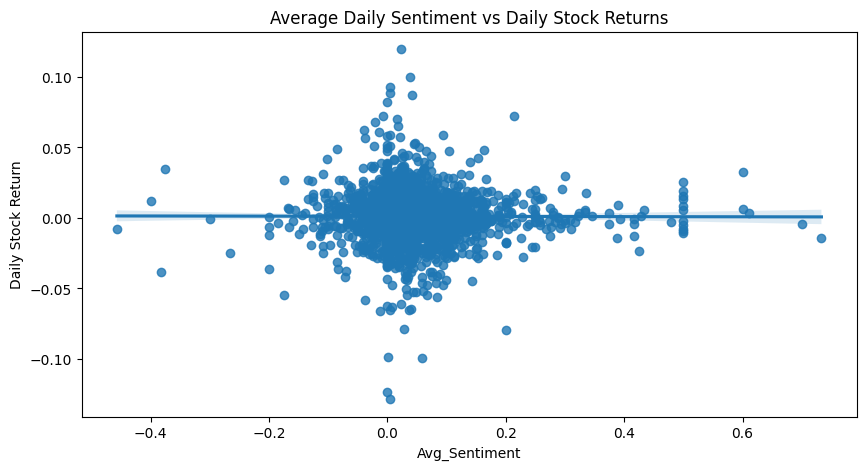

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
# merged contains the average daily sentiment under 'Avg_Sentiment'
sns.regplot(x="Avg_Sentiment", y="Daily_Return", data=merged)
plt.title("Average Daily Sentiment vs Daily Stock Returns")
plt.xlabel("Avg_Sentiment")
plt.ylabel("Daily Stock Return")
plt.show()


# 📌 Summary of Task 3

### ✔️ Dates normalized and aligned  
### ✔️ Sentiment scores computed using VADER  
### ✔️ Stock daily returns calculated  
### ✔️ News & stock data merged into one dataset  
### ✔️ Pearson correlation computed  
### ✔️ Visual analysis provided  

This completes Task 3 and forms the foundation for predictive modeling and dashboards in Task 4.
